In [299]:
from sklearn.datasets import  load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [300]:
def explorer_dataset(X,y,mask=None):
    #1. appliquer le masque si fourni 
    if mask is not None:
        X = X[mask]
        y = y[mask]
    #2. afficher des infos sur les données
    print("Forme des données (lignes, colonnes) :", X.shape)
    #3. afficher la répartition des classes
    print("Classes possibles :", set(y))
    #4. afficher le nombre d'exemples dans chaque classe
    for cls in set(y):
        print(f"Nombre d'exemples dans la classe {cls} : {sum(y == cls)} ({sum(y == cls) / len(y) * 100:.2f}%)")

In [301]:
X, y =  load_breast_cancer(return_X_y=True)
explorer_dataset(X, y)

Forme des données (lignes, colonnes) : (569, 30)
Classes possibles : {np.int64(0), np.int64(1)}
Nombre d'exemples dans la classe 0 : 212 (37.26%)
Nombre d'exemples dans la classe 1 : 357 (62.74%)


Check qualité
Dataset complet

In [302]:
X, y =  load_breast_cancer(return_X_y=True)
explorer_dataset(X,y)

Forme des données (lignes, colonnes) : (569, 30)
Classes possibles : {np.int64(0), np.int64(1)}
Nombre d'exemples dans la classe 0 : 212 (37.26%)
Nombre d'exemples dans la classe 1 : 357 (62.74%)


Dataset juste sur y==0

In [303]:
X, y =  load_breast_cancer(return_X_y=True)
mask = (y == 0)
explorer_dataset(X, y, mask)

Forme des données (lignes, colonnes) : (212, 30)
Classes possibles : {np.int64(0)}
Nombre d'exemples dans la classe 0 : 212 (100.00%)


cas adversarial : affichez la répartition en pourcentage

In [304]:
X, y =  load_breast_cancer(return_X_y=True)
explorer_dataset(X,y)
mask = (y == 0)
explorer_dataset(X, y, mask)


Forme des données (lignes, colonnes) : (569, 30)
Classes possibles : {np.int64(0), np.int64(1)}
Nombre d'exemples dans la classe 0 : 212 (37.26%)
Nombre d'exemples dans la classe 1 : 357 (62.74%)
Forme des données (lignes, colonnes) : (212, 30)
Classes possibles : {np.int64(0)}
Nombre d'exemples dans la classe 0 : 212 (100.00%)


Modèle possible pour classification surpervisé :
-régression logistique
-arbres de décision
-Naive Bayes
-Random Forest
-Gradient Boosting
-SVM

In [305]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    # 1. Entraîner le modèle sur les données d'entraînement (.fit)
    modele.fit(X_train, y_train)
    # 2. Prédire sur des données jamais vues (.predict)
    y_pred = modele.predict(X_test)
    # 3. Mesurer : quelle proportion de bonnes réponses ?
    return accuracy_score(y_test, y_pred)*100

In [306]:
# modele : régression logistique (LogisticRegression)

X, y =  load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
modele = LogisticRegression(max_iter=10000)
score = entrainer_et_evaluer(modele,X_train,X_test,y_train,y_test)
print(f"Accuracy regression logistique : {score:.2f}%")

Accuracy regression logistique : 96.49%


In [307]:
def arene(X_train, X_test, y_train, y_test):

    #1. définir les modèles à comparer
    dict_modeles = {
        "Logistic Regression": LogisticRegression(max_iter=10000),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=20)
    }
    #2. entraîner et évaluer chaque modèle, stocker les résultats
    results = []
    for nom, modele in dict_modeles.items():
        accuracy_score = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        results.append((nom, accuracy_score, modele))
    #3. Trier par accuracy décroissante
    results.sort(key=lambda x: x[1], reverse=True)
    print("\nClassement :")
    for i, (nom, accuracy, modele) in enumerate(results, start=1):
        print(f"{i}. {nom} : {accuracy:.2f}%")
    #4 renvoyer tous les resultats
    return results



In [308]:
X, y =  load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
arene(X_train, X_test, y_train, y_test)


Classement :
1. Logistic Regression : 96.49%
2. KNN : 93.86%
3. Decision Tree : 92.11%


[('Logistic Regression',
  96.49122807017544,
  LogisticRegression(max_iter=10000)),
 ('KNN', 93.85964912280701, KNeighborsClassifier(n_neighbors=20)),
 ('Decision Tree',
  92.10526315789474,
  DecisionTreeClassifier(max_depth=5, random_state=42))]

In [309]:
from sklearn.cluster import KMeans
def clustering_aveugle(X):
    #1. charger le modèle de clustering (KMeans)
    modele = KMeans(n_clusters=2, random_state=42)
    #2. faire l'entrainer_et_evaluer sur les données (fit_predict)
    modele.fit_predict(X)
    return modele.labels_

In [310]:
X, y =  load_breast_cancer(return_X_y=True)
labels_cluster = clustering_aveugle(X)
print("Labels de cluster attribués à chaque point :", labels_cluster)
#comparer les labels de cluster avec les vraies étiquettes
from sklearn.datasets import load_wine
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, labels_cluster)
print("Matrice de confusion entre les vraies étiquettes et les labels de cluster :")
print(cm)
print("Interprétation :")
print(cm[0,0], "points de la classe 0 ont été regroupés ensemble (cluster 0)")
print(cm[0,1], "points de la classe 0 ont été attribués au cluster 1")
print(cm[1,0], "points de la classe 1 ont été attribués au cluster 0")
print(cm[1,1], "points de la classe 1 ont été regroupés ensemble (cluster 1)")



Labels de cluster attribués à chaque point : [0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1
 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 0 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0
 1 0 0 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 

In [311]:
from sklearn.datasets import  load_wine
X, y =  load_wine(return_X_y=True)
explorer_dataset(X, y)
x_train, x_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
results = arene(x_train, x_test, y_train, y_test)

Forme des données (lignes, colonnes) : (178, 13)
Classes possibles : {np.int64(0), np.int64(1), np.int64(2)}
Nombre d'exemples dans la classe 0 : 59 (33.15%)
Nombre d'exemples dans la classe 1 : 71 (39.89%)
Nombre d'exemples dans la classe 2 : 48 (26.97%)

Classement :
1. Logistic Regression : 94.44%
2. Decision Tree : 94.44%
3. KNN : 77.78%


In [312]:
X, y =  load_wine(return_X_y=True)
mask = (y != 0)
X_filtered = X[mask]
y_filtered = y[mask]
explorer_dataset(X_filtered, y_filtered)
x_train, x_test, y_train, y_test = train_test_split(
X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)
results = arene(x_train, x_test, y_train, y_test)

Forme des données (lignes, colonnes) : (119, 13)
Classes possibles : {np.int64(1), np.int64(2)}
Nombre d'exemples dans la classe 1 : 71 (59.66%)
Nombre d'exemples dans la classe 2 : 48 (40.34%)

Classement :
1. Logistic Regression : 95.83%
2. Decision Tree : 87.50%
3. KNN : 58.33%



Classement :
1. Logistic Regression : 96.49%
2. KNN : 93.86%
3. Decision Tree : 92.11%


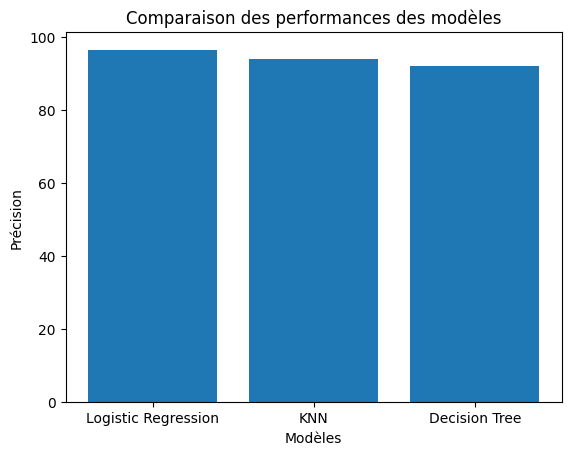

In [315]:
#tracer le graph en barre des accuracies des différents modèles sur le dataset breast cancer
import matplotlib.pyplot as plt
X, y =  load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
results = arene(X_train, X_test, y_train, y_test)
noms = [nom for nom, accuracy, modele in results]
accuracies = [accuracy for nom, accuracy, modele in results]
plt.bar(noms, accuracies)
plt.xlabel('Modèles')
plt.ylabel('Précision')
plt.title('Comparaison des performances des modèles')
plt.show()



Classement :
1. Logistic Regression : 96.49%
2. KNN : 93.86%
3. Decision Tree : 92.11%


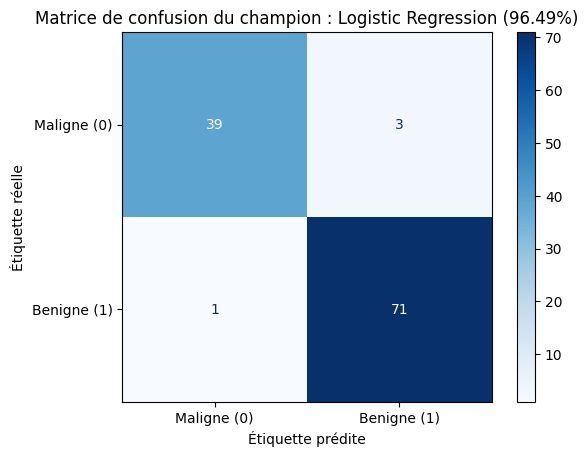

In [316]:
#tracer le graph de la confusion_matric du champion
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
X, y =  load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
results = arene(X_train, X_test, y_train, y_test)
champion_nom, champion_acc, champion_modele = results[0]
y_pred = champion_modele.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matrice de confusion du champion : {champion_nom} ({champion_acc:.2f}%)')
disp.ax_.set_xticklabels(['Maligne (0)', 'Benigne (1)'])
disp.ax_.set_yticklabels(['Maligne (0)', 'Benigne (1)'])
disp.ax_.set_xlabel('Étiquette prédite')
disp.ax_.set_ylabel('Étiquette réelle')

plt.show()
